In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [ ]:
df_main = pd.read_csv(r'kidney_disease_dataset.csv')

In [ ]:
df_main['Target'] = df_main['Target'].replace({
    'Low_Risk':'Disease',
    'Severe_Disease': 'Disease',
    'High_Risk': 'Disease',
    'Moderate_Risk': 'Disease'
})

In [ ]:
df_main['Target'].value_counts()

In [ ]:
object_columns = [
    'Red blood cells in urine','Pus cells in urine','Pus cell clumps in urine','Bacteria in urine','Hypertension (yes/no)',
    'Diabetes mellitus (yes/no)','Coronary artery disease (yes/no)','Appetite (good/poor)','Pedal edema (yes/no)','Anemia (yes/no)',
    'Family history of chronic kidney disease','Smoking status','Physical activity level','Urinary sediment microscopy results'
]

from sklearn.preprocessing import LabelEncoder
def label_encode_object_columns(df_main,save_path='label_encoders'):
    df_encoded = df_main.copy()
    label_encoders = {}



    for col in object_columns:
        LE = LabelEncoder()
        df_encoded[col] = LE.fit_transform(df_encoded[col].astype(str))
        label_encoders[col] = LE



    return df_encoded, label_encoders
df_encoded,label_encoder  = label_encode_object_columns(df_main)

In [ ]:

target_mapping = {'No_Disease':0,
                  'Disease':1}
df_encoded['Target'] = df_encoded['Target'].map(target_mapping)

In [ ]:

!pip install catboost

In [ ]:
from collections import Counter
from catboost import CatBoostClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay


CAT_boost_selected_features = [
    "Pus cells in urine", "Age of the patient", "Body Mass Index (BMI)",
    "Sodium level (mEq/L)", "Estimated Glomerular Filtration Rate (eGFR)",
    "Urine protein-to-creatinine ratio", "Duration of diabetes mellitus (years)",
    "C-reactive protein (CRP) level", "Sugar in urine", "Cystatin C level",
    "Interleukin-6 (IL-6) level", "White blood cell count (cells/cumm)",
    "Cholesterol level", "Serum phosphate level", "Serum albumin level",
    "Family history of chronic kidney disease", "Bacteria in urine", "Appetite (good/poor)"
]

TARGET_COLUMN = "Target"


df_fe = df_encoded.copy()


df_fe["IL6_albumin_ratio"] = df_fe["Interleukin-6 (IL-6) level"] / df_fe["Serum albumin level"]
df_fe["protein_eGFR_ratio"] = df_fe["Urine protein-to-creatinine ratio"] / df_fe["Estimated Glomerular Filtration Rate (eGFR)"]
df_fe["CRP_WBC_ratio"] = df_fe["C-reactive protein (CRP) level"] / df_fe["White blood cell count (cells/cumm)"]


df_fe["log_Cystatin_C"] = np.log1p(df_fe["Cystatin C level"])
df_fe["sqrt_Cholesterol"] = np.sqrt(df_fe["Cholesterol level"])


df_fe["Age_group"] = pd.cut(df_fe["Age of the patient"], bins=[0, 30, 50, 70, 100], labels=["<30", "30-50", "50-70", "70+"])
df_fe["BMI_category"] = pd.cut(df_fe["Body Mass Index (BMI)"], bins=[0, 18.5, 25, 30, np.inf], labels=["Underweight", "Normal", "Overweight", "Obese"])


appetite_counts = df_fe["Appetite (good/poor)"].value_counts()
df_fe["Appetite_encoded"] = df_fe["Appetite (good/poor)"].map(appetite_counts)


for col in CAT_boost_selected_features:
    df_fe[col + "_missing_flag"] = df_fe[col].isnull().astype(int)


categorical_cols = [
    "Age_group", "BMI_category", "Appetite (good/poor)",
    "Family history of chronic kidney disease", "Pus cells in urine",
    "Sugar in urine", "Bacteria in urine"
]


X = df_fe.drop(columns=[TARGET_COLUMN])
y = df_fe[TARGET_COLUMN]


X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)


class_counts = Counter(y_train)
total = sum(class_counts.values())
weights = {cls: total / count for cls, count in class_counts.items()}


model = CatBoostClassifier(
    verbose=False,
    # scale_pos_weight=1.44,
    iterations=1000,
    depth=6,
    learning_rate=0.03,
    l2_leaf_reg=4,
    random_strength=1,
    bagging_temperature=0.5,
    border_count=128,
    early_stopping_rounds=100,
    auto_class_weights='Balanced',
)


model.fit(
    X_train, y_train,
    cat_features=categorical_cols,
    eval_set=(X_test, y_test)
)


preds = model.predict(X_test)
print("\nClassification Report: ")
print(classification_report(y_test, preds))

cm = confusion_matrix(y_test, preds)
ConfusionMatrixDisplay(confusion_matrix=cm).plot(cmap='Blues')
plt.title("Confusion Matrix - CatBoost")
plt.tight_layout()
plt.show()

In [ ]:
from collections import Counter
from catboost import CatBoostClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd


CAT_boost_selected_features = [
    "Pus cells in urine", "Age of the patient", "Body Mass Index (BMI)",
    "Sodium level (mEq/L)", "Estimated Glomerular Filtration Rate (eGFR)",
    "Urine protein-to-creatinine ratio", "Duration of diabetes mellitus (years)",
    "C-reactive protein (CRP) level", "Sugar in urine", "Cystatin C level",
    "Interleukin-6 (IL-6) level", "White blood cell count (cells/cumm)",
    "Cholesterol level", "Serum phosphate level", "Serum albumin level",
    "Family history of chronic kidney disease", "Bacteria in urine", "Appetite (good/poor)"
]

TARGET_COLUMN = "Target"

categorical_cols = [
    "Age_group", "BMI_category", "Appetite (good/poor)",
    "Family history of chronic kidney disease", "Pus cells in urine",
    "Sugar in urine", "Bacteria in urine"
]


df_fe = df_encoded.copy()


df_fe["IL6_albumin_ratio"] = df_fe["Interleukin-6 (IL-6) level"] / df_fe["Serum albumin level"]
df_fe["protein_eGFR_ratio"] = df_fe["Urine protein-to-creatinine ratio"] / df_fe["Estimated Glomerular Filtration Rate (eGFR)"]
df_fe["CRP_WBC_ratio"] = df_fe["C-reactive protein (CRP) level"] / df_fe["White blood cell count (cells/cumm)"]
df_fe["phosphate_albumin_ratio"] = df_fe["Serum phosphate level"] / df_fe["Serum albumin level"]
df_fe["cholesterol_BMI_ratio"] = df_fe["Cholesterol level"] / df_fe["Body Mass Index (BMI)"]

df_fe["log_Cystatin_C"] = np.log1p(df_fe["Cystatin C level"])
df_fe["sqrt_Cholesterol"] = np.sqrt(df_fe["Cholesterol level"])
df_fe["BMI_squared"] = df_fe["Body Mass Index (BMI)"] ** 2
df_fe["eGFR_squared"] = df_fe["Estimated Glomerular Filtration Rate (eGFR)"] ** 2


df_fe["eGFR_IL6_interaction"] = df_fe["Estimated Glomerular Filtration Rate (eGFR)"] * df_fe["Interleukin-6 (IL-6) level"]
df_fe["CRP_albumin_interaction"] = df_fe["C-reactive protein (CRP) level"] * df_fe["Serum albumin level"]

df_fe["is_eGFR_low"] = (df_fe["Estimated Glomerular Filtration Rate (eGFR)"] < 60).astype(int)
df_fe["is_CRP_elevated"] = (df_fe["C-reactive protein (CRP) level"] > 10).astype(int)


df_fe["Age_group"] = pd.cut(df_fe["Age of the patient"], bins=[0, 30, 50, 70, 100], labels=["<30", "30-50", "50-70", "70+"])
df_fe["BMI_category"] = pd.cut(df_fe["Body Mass Index (BMI)"], bins=[0, 18.5, 25, 30, np.inf], labels=["Underweight", "Normal", "Overweight", "Obese"])


appetite_counts = df_fe["Appetite (good/poor)"].value_counts()
df_fe["Appetite_encoded"] = df_fe["Appetite (good/poor)"].map(appetite_counts)


for col in CAT_boost_selected_features:
    df_fe[col + "_missing_flag"] = df_fe[col].isnull().astype(int)


df_fe["mean_eGFR_by_age_bmi"] = df_fe.groupby(["Age_group", "BMI_category"])["Estimated Glomerular Filtration Rate (eGFR)"].transform("mean")


df_fe["urine_findings_sum"] = (
    df_fe["Pus cells in urine"].astype(str).map({"present": 1, "absent": 0, "missing": 0}) +
    df_fe["Sugar in urine"].astype(str).map({"present": 1, "absent": 0, "missing": 0}) +
    df_fe["Bacteria in urine"].astype(str).map({"present": 1, "absent": 0, "missing": 0})
)


for col in categorical_cols:
    df_fe[col] = df_fe[col].astype(str).fillna("Missing")


X = df_fe.drop(columns=[TARGET_COLUMN])
y = df_fe[TARGET_COLUMN]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)


class_counts = Counter(y_train)
total = sum(class_counts.values())
weights = {cls: total / count for cls, count in class_counts.items()}

model = CatBoostClassifier(
    verbose=False,
    scale_pos_weight=1.44,
    iterations=1000,
    depth=6,
    learning_rate=0.03,
    l2_leaf_reg=4,
    random_strength=1,
    bagging_temperature=0.5,
    border_count=128,
    early_stopping_rounds=100
)

model.fit(
    X_train, y_train,
    cat_features=categorical_cols,
    eval_set=(X_test, y_test)
)


preds = model.predict(X_test)
print("\n Classification Report:\n", classification_report(y_test, preds))

cm = confusion_matrix(y_test, preds)
ConfusionMatrixDisplay(confusion_matrix=cm).plot(cmap='Blues')
plt.title("Confusion Matrix - CatBoost (Extended Features)")
plt.tight_layout()
plt.show()


In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix


X = df_encoded.drop('Target', axis=1)
y = df_encoded['Target']


scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)


logreg = LogisticRegression(random_state=42)
logreg.fit(X_train, y_train)


y_pred = logreg.predict(X_test)


print("Classification Report:\n", classification_report(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(confusion_matrix=cm).plot(cmap='Blues')
plt.title("Confusion Matrix - LogisticRegression")
plt.tight_layout()
plt.show()

In [ ]:
from collections import Counter
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay


CAT_boost_selected_features = [
    "Pus cells in urine", "Age of the patient", "Body Mass Index (BMI)",
    "Sodium level (mEq/L)", "Estimated Glomerular Filtration Rate (eGFR)",
    "Urine protein-to-creatinine ratio", "Duration of diabetes mellitus (years)",
    "C-reactive protein (CRP) level", "Sugar in urine", "Cystatin C level",
    "Interleukin-6 (IL-6) level", "White blood cell count (cells/cumm)",
    "Cholesterol level", "Serum phosphate level", "Serum albumin level",
    "Family history of chronic kidney disease", "Bacteria in urine", "Appetite (good/poor)"
]

TARGET_COLUMN = "Target"


df_fe = df_encoded.copy()


df_fe["IL6_albumin_ratio"] = df_fe["Interleukin-6 (IL-6) level"] / df_fe["Serum albumin level"]
df_fe["protein_eGFR_ratio"] = df_fe["Urine protein-to-creatinine ratio"] / df_fe["Estimated Glomerular Filtration Rate (eGFR)"]
df_fe["CRP_WBC_ratio"] = df_fe["C-reactive protein (CRP) level"] / df_fe["White blood cell count (cells/cumm)"]


df_fe["log_Cystatin_C"] = np.log1p(df_fe["Cystatin C level"])
df_fe["sqrt_Cholesterol"] = np.sqrt(df_fe["Cholesterol level"])


df_fe["IL6_CRP_interaction"] = df_fe["Interleukin-6 (IL-6) level"] * df_fe["C-reactive protein (CRP) level"]
df_fe["BMI_sodium_interaction"] = df_fe["Body Mass Index (BMI)"] * df_fe["Sodium level (mEq/L)"]
df_fe["BMI_squared"] = df_fe["Body Mass Index (BMI)"] ** 2
df_fe["eGFR_squared"] = df_fe["Estimated Glomerular Filtration Rate (eGFR)"] ** 2


df_fe["Age_group"] = pd.cut(df_fe["Age of the patient"], bins=[0, 30, 50, 70, 100], labels=["<30", "30-50", "50-70", "70+"])
df_fe["BMI_category"] = pd.cut(df_fe["Body Mass Index (BMI)"], bins=[0, 18.5, 25, 30, np.inf], labels=["Underweight", "Normal", "Overweight", "Obese"])


appetite_counts = df_fe["Appetite (good/poor)"].value_counts()
df_fe["Appetite_encoded"] = df_fe["Appetite (good/poor)"].map(appetite_counts)


for col in CAT_boost_selected_features:
    df_fe[col + "_missing_flag"] = df_fe[col].isnull().astype(int)


categorical_cols = [
    "Age_group", "BMI_category", "Appetite (good/poor)",
    "Family history of chronic kidney disease", "Pus cells in urine",
    "Sugar in urine", "Bacteria in urine"
]

for col in categorical_cols:
    df_fe[col] = df_fe[col].astype(str).fillna("missing")
    le = LabelEncoder()
    df_fe[col] = le.fit_transform(df_fe[col])


X = df_fe.drop(columns=[TARGET_COLUMN])
y = df_fe[TARGET_COLUMN]


class_counts = Counter(y)
total = sum(class_counts.values())
weights = {cls: total / count for cls, count in class_counts.items()}
scale_pos_weight = weights[0] / weights[1] if 0 in weights and 1 in weights else 1


X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)


xgb_model = XGBClassifier(
    use_label_encoder=False,
    eval_metric='logloss',
    scale_pos_weight=1.4,
    n_estimators=1000,
    max_depth=6,
    learning_rate=0.03,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_lambda=4,
    random_state=42
)

xgb_model.fit(X_train, y_train)


preds = xgb_model.predict(X_test)
print("\nClassification Report: ")
print(classification_report(y_test, preds))

cm = confusion_matrix(y_test, preds)
ConfusionMatrixDisplay(confusion_matrix=cm).plot(cmap='Blues')
plt.title("Confusion Matrix - XGBoost")
plt.tight_layout()
plt.show()



 Model: Logistic Regression
              precision    recall  f1-score   support

     Disease       0.20      0.50      0.29       821
  No_Disease       0.80      0.51      0.63      3287

    accuracy                           0.51      4108
   macro avg       0.50      0.51      0.46      4108
weighted avg       0.68      0.51      0.56      4108



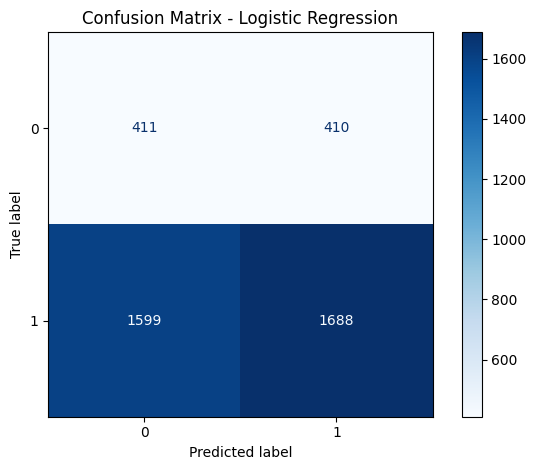


 Model: SVM


In [ ]:
from collections import Counter
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import (
    RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier
)
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.neural_network import MLPClassifier


CAT_boost_selected_features = [
    "Pus cells in urine", "Age of the patient", "Body Mass Index (BMI)",
    "Sodium level (mEq/L)", "Estimated Glomerular Filtration Rate (eGFR)",
    "Urine protein-to-creatinine ratio", "Duration of diabetes mellitus (years)",
    "C-reactive protein (CRP) level", "Sugar in urine", "Cystatin C level",
    "Interleukin-6 (IL-6) level", "White blood cell count (cells/cumm)",
    "Cholesterol level", "Serum phosphate level", "Serum albumin level",
    "Family history of chronic kidney disease", "Bacteria in urine", "Appetite (good/poor)"
]

TARGET_COLUMN = "Target"


df_fe = df_encoded.copy()

df_fe["IL6_albumin_ratio"] = df_fe["Interleukin-6 (IL-6) level"] / df_fe["Serum albumin level"]
df_fe["protein_eGFR_ratio"] = df_fe["Urine protein-to-creatinine ratio"] / df_fe["Estimated Glomerular Filtration Rate (eGFR)"]
df_fe["CRP_WBC_ratio"] = df_fe["C-reactive protein (CRP) level"] / df_fe["White blood cell count (cells/cumm)"]
df_fe["log_Cystatin_C"] = np.log1p(df_fe["Cystatin C level"])
df_fe["sqrt_Cholesterol"] = np.sqrt(df_fe["Cholesterol level"])
df_fe["IL6_CRP_interaction"] = df_fe["Interleukin-6 (IL-6) level"] * df_fe["C-reactive protein (CRP) level"]
df_fe["BMI_sodium_interaction"] = df_fe["Body Mass Index (BMI)"] * df_fe["Sodium level (mEq/L)"]
df_fe["BMI_squared"] = df_fe["Body Mass Index (BMI)"] ** 2
df_fe["eGFR_squared"] = df_fe["Estimated Glomerular Filtration Rate (eGFR)"] ** 2
df_fe["Age_group"] = pd.cut(df_fe["Age of the patient"], bins=[0, 30, 50, 70, 100], labels=["<30", "30-50", "50-70", "70+"])
df_fe["BMI_category"] = pd.cut(df_fe["Body Mass Index (BMI)"], bins=[0, 18.5, 25, 30, np.inf], labels=["Underweight", "Normal", "Overweight", "Obese"])

appetite_counts = df_fe["Appetite (good/poor)"].value_counts()
df_fe["Appetite_encoded"] = df_fe["Appetite (good/poor)"].map(appetite_counts)

for col in CAT_boost_selected_features:
    df_fe[col + "_missing_flag"] = df_fe[col].isnull().astype(int)


categorical_cols = [
    "Age_group", "BMI_category", "Appetite (good/poor)",
    "Family history of chronic kidney disease", "Pus cells in urine",
    "Sugar in urine", "Bacteria in urine"
]

for col in categorical_cols:
    df_fe[col] = df_fe[col].astype(str).fillna("missing")
    le = LabelEncoder()
    df_fe[col] = le.fit_transform(df_fe[col])


X = df_fe.drop(columns=[TARGET_COLUMN])
y = df_fe[TARGET_COLUMN]


scaler = MinMaxScaler()
X[X.columns] = scaler.fit_transform(X)


X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)


models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, class_weight='balanced'),
    "SVM": SVC(probability=True, class_weight='balanced'),
    "KNN": KNeighborsClassifier(),
    "Random Forest": RandomForestClassifier(class_weight='balanced'),
    "Decision Tree": DecisionTreeClassifier(class_weight='balanced'),
    "Gradient Boosting": GradientBoostingClassifier(),
    "AdaBoost": AdaBoostClassifier(),
    "Naive Bayes": GaussianNB(),
    "MLP (ANN)": MLPClassifier(hidden_layer_sizes=(100,), max_iter=500)
}


for name, model in models.items():
    print(f"\n Model: {name}")
    model.fit(X_train, y_train)
    preds = model.predict(X_test)

    print(classification_report(y_test, preds))

    cm = confusion_matrix(y_test, preds)
    ConfusionMatrixDisplay(confusion_matrix=cm).plot(cmap='Blues')
    plt.title(f"Confusion Matrix - {name}")
    plt.tight_layout()
    plt.show()